In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif

In [ ]:
# i.) Loading the dataset
df = pd.read_csv('diabetes/diabetes_prediction_dataset.csv')
 
# ii.) Exploratory Data Analysis and Visualization

# Define features
numeric_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorical_features = ['gender', 'hypertension', 'heart_disease', 'smoking_history', 'diabetes']

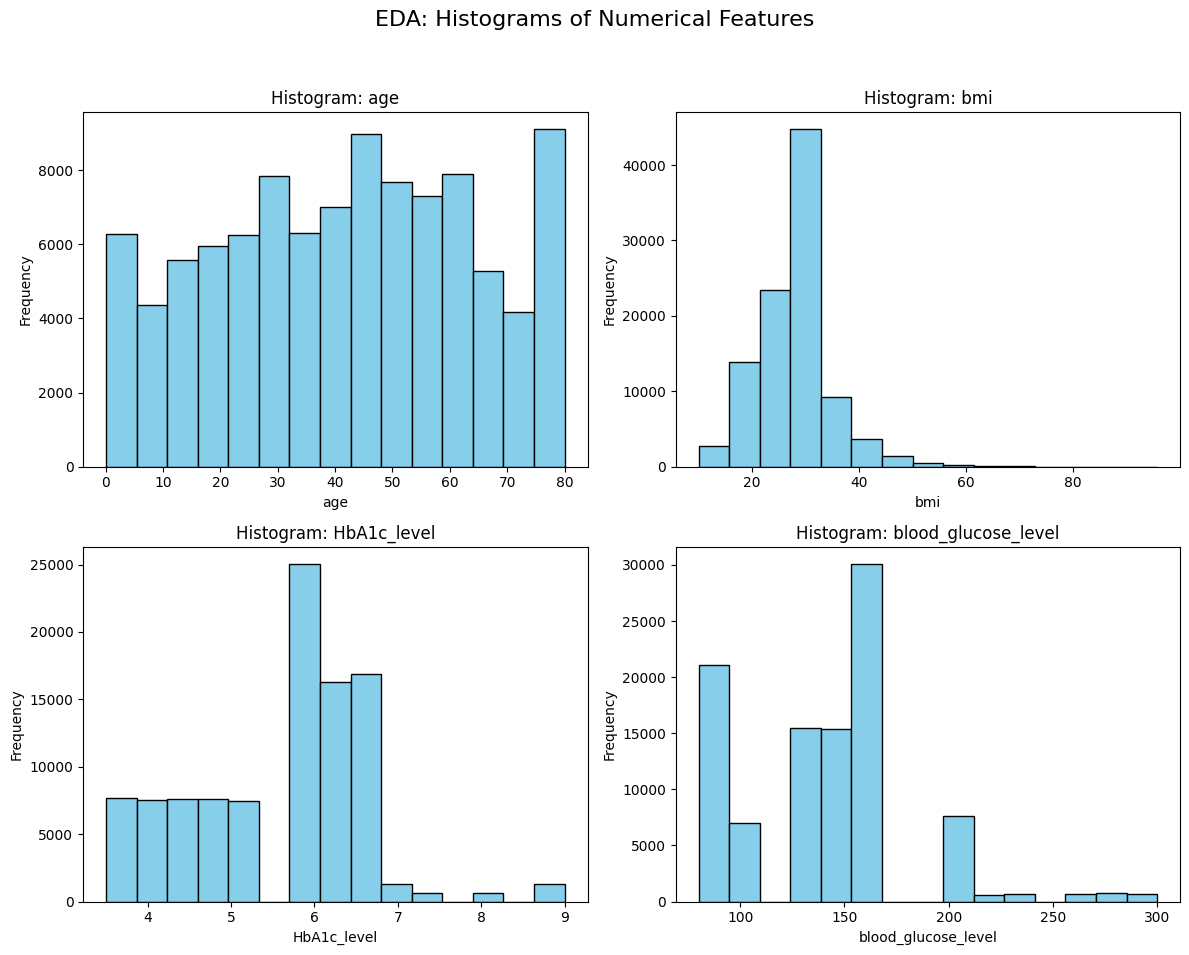

In [3]:
# Grid 1: Histograms (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('EDA: Histograms of Numerical Features', fontsize=16)
axes_flat = axes.flatten()

for i, feature in enumerate(numeric_features):
    ax = axes_flat[i]
    # rwidth=1.0 ensures bars touch
    ax.hist(df[feature], bins=15, color='skyblue', edgecolor='black', rwidth=1.0)
    ax.set_title(f'Histogram: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('diabetes_histograms.eps', format='eps')
plt.show()

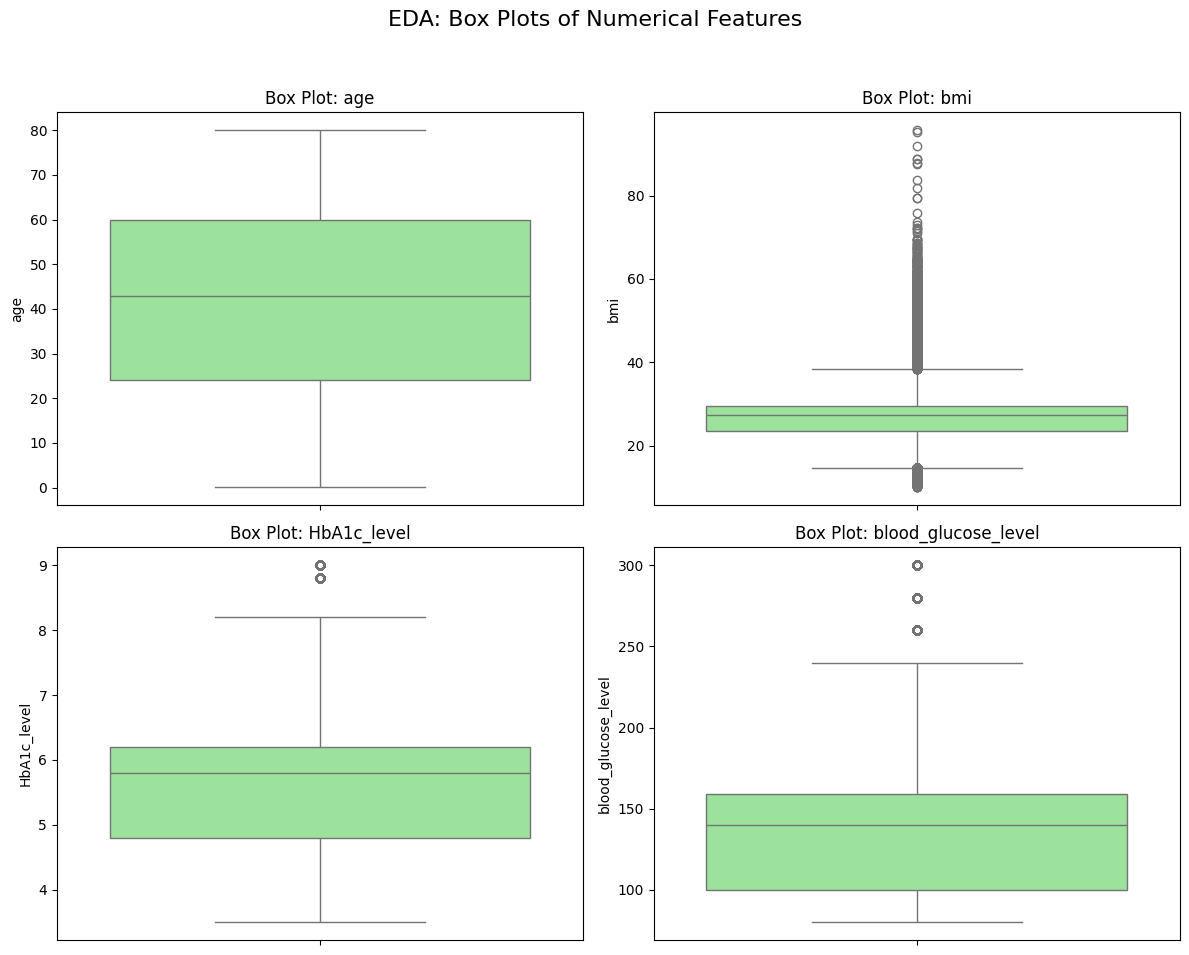

In [4]:
# Grid 2: Box Plots (2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('EDA: Box Plots of Numerical Features', fontsize=16)
axes_flat = axes.flatten()

for i, feature in enumerate(numeric_features):
    ax = axes_flat[i]
    sns.boxplot(y=df[feature], ax=ax, color='lightgreen')
    ax.set_title(f'Box Plot: {feature}')
    ax.set_ylabel(feature)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('diabetes_boxplots.eps', format='eps')
plt.show()

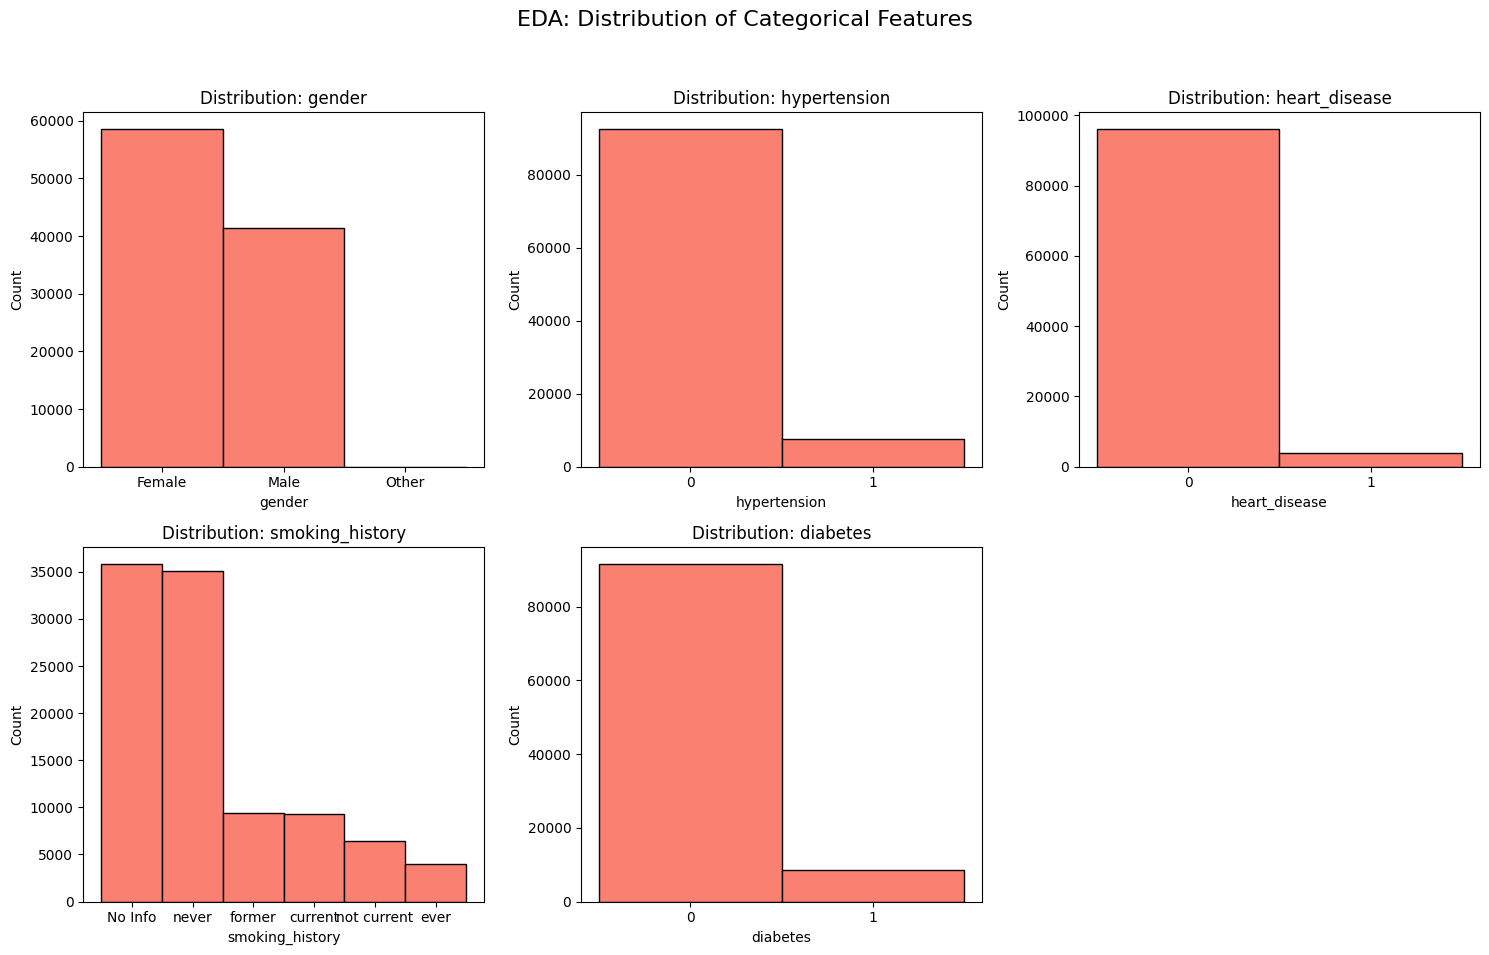

In [5]:
# Grid 3: Categorical Bar Charts (2x3 Grid)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('EDA: Distribution of Categorical Features', fontsize=16)
axes_flat = axes.flatten()

for i, feature in enumerate(categorical_features):
    ax = axes_flat[i]
    counts = df[feature].value_counts()
    # width=1.0 ensures bars touch
    ax.bar(counts.index.astype(str), counts.values, width=1.0, color='salmon', edgecolor='black')
    ax.set_title(f'Distribution: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

# Hide empty subplot if any
if len(categorical_features) < len(axes_flat):
    axes_flat[-1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('diabetes_categorical.eps', format='eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


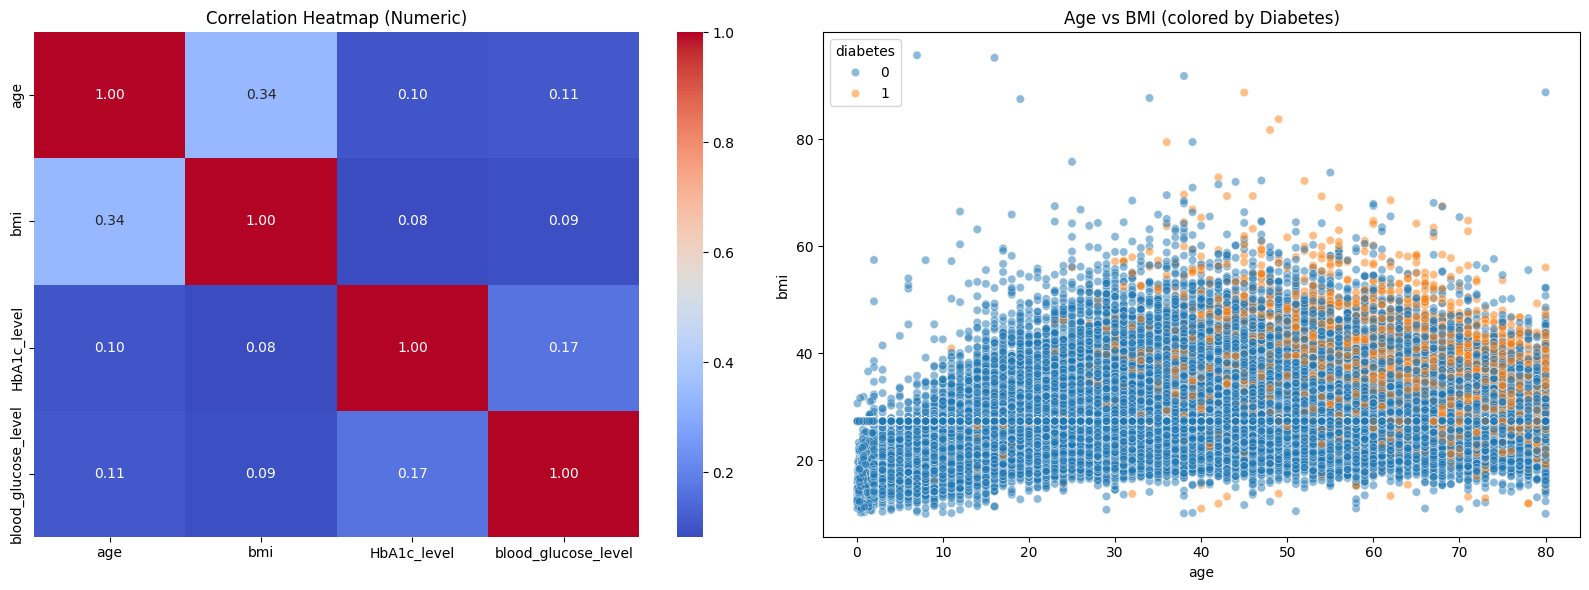

In [6]:
# Grid 4: Heatmap & Scatter (1x2 Grid)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap (Numeric)
numeric_corr_df = df[numeric_features]
sns.heatmap(numeric_corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Correlation Heatmap (Numeric)')

# Scatter: Age vs BMI (Hue: Diabetes)
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df, ax=axes[1], alpha=0.5)
axes[1].set_title('Age vs BMI (colored by Diabetes)')

plt.tight_layout()
plt.savefig('diabetes_bivariate.eps', format='eps')
plt.show()

In [7]:
# iii.) Data Preprocessing

# Handle missing values
df.dropna(inplace=True)

# Encode Categorical Variables
le = LabelEncoder()
df_encoded = df.copy()
# Encode gender and smoking_history
for col in ['gender', 'smoking_history']:
    df_encoded[col] = le.fit_transform(df[col])

# Separate Features (X) and Target (y)
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

# Standardize (for ANOVA and Splitting)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=X.columns)

# MinMax (for Chi-Square to ensure non-negative inputs)
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

In [8]:
# iv.) Feature Selection

# 1. Chi-Square Test
print("\n--- Chi-square Test Results ---")
chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_minmax_df, y)
chi2_scores = pd.DataFrame({'Feature': X.columns, 'Score': chi2_selector.scores_})
print(chi2_scores.sort_values(by='Score', ascending=False))

# 2. ANOVA (F-test)
print("\n--- ANOVA Results ---")
anova_selector = SelectKBest(f_classif, k='all')
anova_selector.fit(X_std_df, y)
anova_scores = pd.DataFrame({'Feature': X.columns, 'Score': anova_selector.scores_})
print(anova_scores.sort_values(by='Score', ascending=False))


--- Chi-square Test Results ---
               Feature        Score
2         hypertension  3620.485416
3        heart_disease  2832.761069
7  blood_glucose_level  2283.793832
6          HbA1c_level  1650.198643
1                  age  1010.146578
4      smoking_history   291.297554
5                  bmi   136.455851
0               gender    41.022571

--- ANOVA Results ---
               Feature         Score
7  blood_glucose_level  21363.054361
6          HbA1c_level  19122.211184
1                  age   7131.405852
5                  bmi   4816.113932
2         hypertension   4072.706875
3        heart_disease   3038.559564
4      smoking_history    897.017116
0               gender    140.152410


In [9]:
# v.) Data Splitting
# 70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_std, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\n--- Data Splitting Shapes ---")
print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")


--- Data Splitting Shapes ---
Train set: (70000, 8)
Validation set: (15000, 8)
Test set: (15000, 8)
